In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from expense_predictor.analyzer import (
    load_data,
    compute_monthly_totals,
    detect_large_transactions,

)
from expense_predictor.recommendations import generate_recommendations
from expense_predictor.predictor import predict_next

In [5]:
# Adjust path relative to notebook location
df = load_data("../data/transactions.csv")

df.head()

Amount column cleaned. Range: 0.05 to 2500.0
Sample amounts: [45.0, 17.33, 5.5, 11.78, 10.0]
   transaction_id                      date    category  amount
0               1 2022-07-06 05:57:10+00:00  Restuarant   45.00
1               3 2022-07-06 05:58:25+00:00      Market   17.33
2               4 2022-07-06 05:59:00+00:00  Restuarant    5.50
3               5 2022-07-06 05:59:15+00:00      Market   11.78
4               6 2022-07-06 05:59:41+00:00  Restuarant   10.00


,transaction_id,date,category,amount
0,1,2022-07-06 05:57:10+00:00,Restuarant,45.00
1,3,2022-07-06 05:58:25+00:00,Market,17.33
2,4,2022-07-06 05:59:00+00:00,Restuarant,5.50
3,5,2022-07-06 05:59:15+00:00,Market,11.78
4,6,2022-07-06 05:59:41+00:00,Restuarant,10.00


In [6]:
monthly_totals = compute_monthly_totals(df)

monthly_totals

date
2022-07-31 00:00:00+00:00    2868.78
2022-08-31 00:00:00+00:00    1307.52
2022-09-30 00:00:00+00:00    1338.48
2022-10-31 00:00:00+00:00    2001.12
2022-11-30 00:00:00+00:00    1017.81
2022-12-31 00:00:00+00:00    1605.53
2023-01-31 00:00:00+00:00    2162.19
2023-02-28 00:00:00+00:00    1540.84
2023-03-31 00:00:00+00:00    2274.61
2023-04-30 00:00:00+00:00    2224.88
2023-05-31 00:00:00+00:00    2599.92
2023-06-30 00:00:00+00:00    1935.36
2023-07-31 00:00:00+00:00    5192.72
2023-08-31 00:00:00+00:00    1123.74
2023-09-30 00:00:00+00:00    1629.95
2023-10-31 00:00:00+00:00    1728.26
2023-11-30 00:00:00+00:00    1428.31
2023-12-31 00:00:00+00:00    1810.44
2024-01-31 00:00:00+00:00    4068.93
2024-02-29 00:00:00+00:00    1250.66
2024-03-31 00:00:00+00:00    1559.18
2024-04-30 00:00:00+00:00    1706.30
2024-05-31 00:00:00+00:00    4021.46
2024-06-30 00:00:00+00:00    2644.02
2024-07-31 00:00:00+00:00    5509.49
2024-08-31 00:00:00+00:00    2194.54
2024-09-30 00:00:00+00:00    3068

In [7]:
unusual = detect_large_transactions(df)

unusual

,transaction_id,date,category,amount
66,68,2022-07-28 19:18:45+00:00,Motel,675.00
67,69,2022-07-28 19:19:02+00:00,Travel,733.25
74,76,2022-07-29 14:44:10+00:00,Travel,260.00
124,126,2022-08-12 12:13:20+00:00,Learning,220.00
231,233,2022-09-06 16:20:41+00:00,Events,200.00
711,713,2022-12-14 05:17:25+00:00,Clothing,200.00
930,932,2023-01-26 04:17:59+00:00,Learning,441.00
1112,1114,2023-03-01 16:13:18+00:00,Clothing,210.00
1128,1130,2023-03-04 08:51:57+00:00,Restuarant,200.00
1284,1286,2023-04-10 19:16:41+00:00,Restuarant,223.00


In [8]:
prediction = predict_next(monthly_totals)

print(f"Predicted next month spending: {prediction:.2f}")

Predicted next month spending: 3035.08


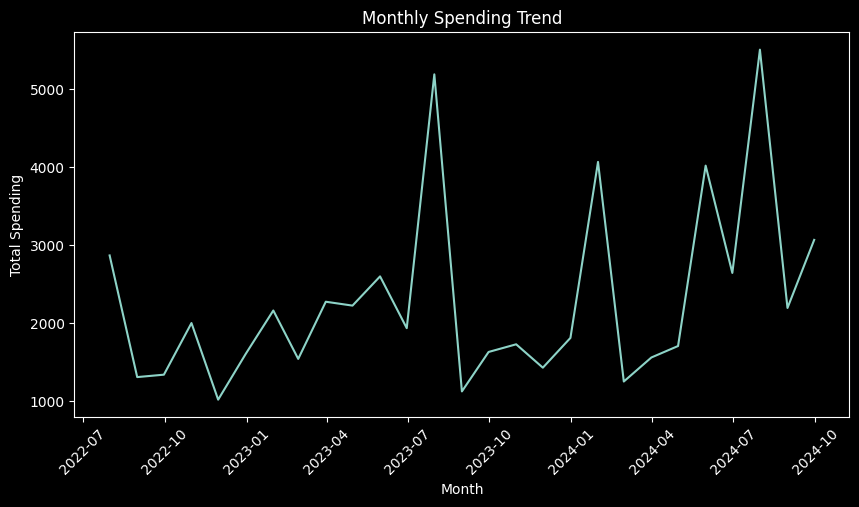

In [9]:
plt.figure(figsize=[10, 5])
plt.plot(monthly_totals.index, monthly_totals.values)
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

In [10]:
recs = generate_recommendations(df)

for r in recs:
    print("-", r)

- You spend the most on 'Restuarant' ($10465.10). Consider reviewing this category to reduce expenses.
- Your spending per transaction looks reasonable. Keep monitoring it.
- You spend across many categories. Creating a monthly budget could help manage spending.
